
# Exercise: Semantic Segmentation with U-Net on Oxford-IIIT Pet Dataset

This notebook demonstrates how to **train, validate, and evaluate a U-Net model**
for **semantic segmentation** using the **Oxford-IIIT Pet Dataset**.

This nodebook is inspired from:
https://colab.research.google.com/github/margaretmz/image-segmentation/blob/main/unet_pet_segmentation.ipynb#scrollTo=5M_beaaBpjNP

## Learning objectives
- Understand semantic segmentation and pixel-wise classification
- Train a U-Net using Keras / TensorFlow
- Evaluate segmentation performance
- Visualize predictions


## 1. Import dependencies

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from tensorflow.keras.layers import *
from tensorflow.keras import layers
from tensorflow.keras.models import Model


## 2. Load Oxford-IIIT Pet Dataset

In [5]:
dataset, info = tfds.load('oxford_iiit_pet:4.*.*',with_info=True)

print(info)

tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='C:\\Users\\bruger\\tensorflow_datasets\\oxford_iiit_pet\\4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'l

## 3. Preprocessing

In [6]:
IMG_SIZE = 128
NUM_CLASSES = 3  # background, pet, border

In [45]:
def resize(input_image, input_mask):
    input_image = tf.image.resize(input_image, (IMG_SIZE, IMG_SIZE), method="nearest")
    input_mask = tf.image.resize(input_mask, (IMG_SIZE, IMG_SIZE), method="nearest")

    return input_image, input_mask 

def augment(input_image, input_mask):
    if tf.random.uniform(()) > 0.5:
        # Random flipping of the image and mask
        input_image = tf.image.flip_left_right(input_image)
        input_mask = tf.image.flip_left_right(input_mask)

    return input_image, input_mask

def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1
  
    return input_image, input_mask

In [46]:
def load_image_train(datapoint):
    input_image = datapoint["image"]
    input_mask = datapoint["segmentation_mask"]
    input_image, input_mask = resize(input_image, input_mask)
    input_image, input_mask = augment(input_image, input_mask)
    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask

def load_image_test(datapoint):
    input_image = datapoint["image"]
    input_mask = datapoint["segmentation_mask"]
    input_image, input_mask = resize(input_image, input_mask)
    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask

In [47]:
train_dataset = dataset["train"].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = dataset["test"].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)

print(train_dataset)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(128, 128, 1), dtype=tf.uint8, name=None))>


## 4. Creating train and test batches

In [10]:
BATCH_SIZE = 64
BUFFER_SIZE = 1000

In [11]:
train_batches = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
train_batches = train_batches.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
validation_batches = test_dataset.take(3000).batch(BATCH_SIZE)
test_batches = test_dataset.skip(3000).take(669).batch(BATCH_SIZE)

print(train_batches)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 128, 128, 1), dtype=tf.uint8, name=None))>


## 5. Visualize dataset

In [12]:
def display(display_list):
  plt.figure(figsize=(10, 10))

  title = ["Input Image", "True Mask", "Predicted Mask"]

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis("off")
  plt.show()

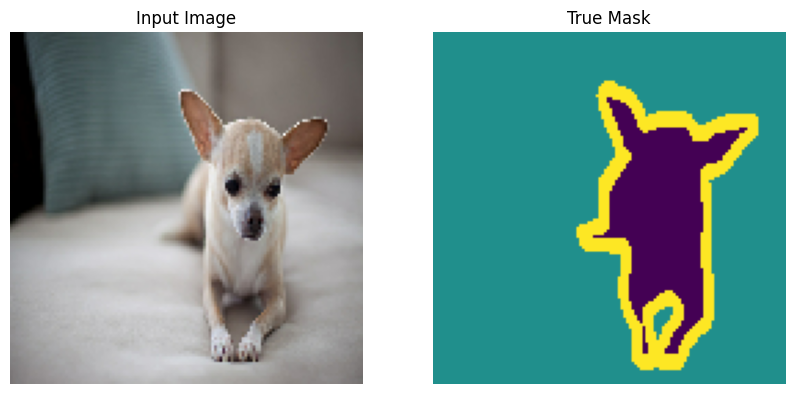

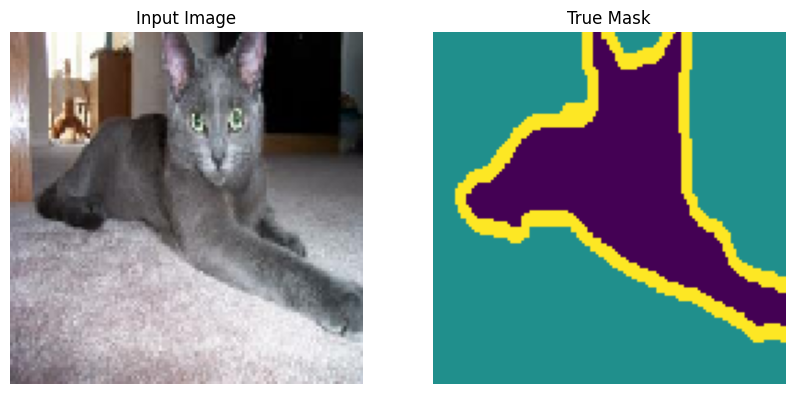

In [13]:
sample_batch = next(iter(test_batches))

for _ in range(2):
    random_index = np.random.choice(sample_batch[0].shape[0])
    sample_image, sample_mask = sample_batch[0][random_index], sample_batch[1][random_index]
    display([sample_image, sample_mask])


## 6. Create Simple U-Net Model

In [14]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, Input

def simple_unet(input_shape=(IMG_SIZE,IMG_SIZE,3), num_classes=NUM_CLASSES):
    inputs = Input(input_shape)

    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling2D()(c2)

    b = Conv2D(128, 3, activation='relu', padding='same')(p2)

    u2 = Conv2DTranspose(64, 2, strides=2, padding='same')(b)
    u2 = Concatenate()([u2, c2])

    u1 = Conv2DTranspose(32, 2, strides=2, padding='same')(u2)
    u1 = Concatenate()([u1, c1])

    outputs = Conv2D(num_classes, 1, activation='softmax')(u1)

    return Model(inputs, outputs)

model_simple = simple_unet()

model_simple.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_simple.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │     32,832 │ conv2d_2[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │     16,416 │ concatenate[0][0] │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │        195 │ concatenate_1[0]… │
│                     │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 142,691 (557.39 KB)

 Trainable params: 142,691 (557.39 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Create Large U-Net Model

In [15]:
def double_conv_block(x, n_filters):

    # Conv2D then ReLU activation
    x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
    # Conv2D then ReLU activation
    x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)

    return x
    
def downsample_block(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = layers.MaxPool2D(2)(f)
    p = layers.Dropout(0.3)(p)

    return f, p

def upsample_block(x, conv_features, n_filters):
    # upsample
    x = layers.Conv2DTranspose(n_filters, 3, 2, padding="same")(x)
    # concatenate 
    x = layers.concatenate([x, conv_features])
    # dropout
    x = layers.Dropout(0.3)(x)
    # Conv2D twice with ReLU activation
    x = double_conv_block(x, n_filters)

    return x

In [16]:
def build_unet_model():

    # inputs
    inputs = layers.Input(shape=(IMG_SIZE,IMG_SIZE,NUM_CLASSES))

    # encoder: contracting path - downsample
    # 1 - downsample
    f1, p1 = downsample_block(inputs, 64)
    # 2 - downsample
    f2, p2 = downsample_block(p1, 128)
    # 3 - downsample
    f3, p3 = downsample_block(p2, 256)
    # 4 - downsample
    f4, p4 = downsample_block(p3, 512)

    # 5 - bottleneck
    bottleneck = double_conv_block(p4, 1024)

    # decoder: expanding path - upsample
    # 6 - upsample
    u6 = upsample_block(bottleneck, f4, 512)
    # 7 - upsample
    u7 = upsample_block(u6, f3, 256)
    # 8 - upsample
    u8 = upsample_block(u7, f2, 128)
    # 9 - upsample
    u9 = upsample_block(u8, f1, 64)

    # outputs
    outputs = layers.Conv2D(3, 1, padding="same", activation = "softmax")(u9)

    # unet model with Keras Functional API
    unet_model = Model(inputs, outputs, name="U-Net")

    return unet_model

In [17]:
unet_model = build_unet_model()

unet_model.compile(optimizer=tf.keras.optimizers.Adam(),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

unet_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_4[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ dropout_2[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_10[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 8, 8, 512) │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 8, 512) │          0 │ max_pooling2d_5[

 Total params: 34,513,475 (131.66 MB)

 Trainable params: 34,513,475 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the U-Net Model

In [18]:
NUM_EPOCHS = 20

TRAIN_LENGTH = info.splits["train"].num_examples
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

VAL_SUBSPLITS = 5
TEST_LENTH = info.splits["test"].num_examples
VALIDATION_STEPS = TEST_LENTH // BATCH_SIZE // VAL_SUBSPLITS

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

# Comment line to use large U-Net model
unet_model = model_simple

history = unet_model.fit(
    train_batches,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=validation_batches,
    epochs=NUM_EPOCHS,
    callbacks=callbacks
)


Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 381ms/step - accuracy: 0.5773 - loss: 0.9382 - val_accuracy: 0.5749 - val_loss: 0.8749
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 381ms/step - accuracy: 0.6133 - loss: 0.8256 - val_accuracy: 0.6520 - val_loss: 0.7960
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 390ms/step - accuracy: 0.6539 - loss: 0.7702 - val_accuracy: 0.6811 - val_loss: 0.7432
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 393ms/step - accuracy: 0.6822 - loss: 0.7216 - val_accuracy: 0.6573 - val_loss: 0.7598
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 394ms/step - accuracy: 0.6924 - loss: 0.6986 - val_accuracy: 0.6864 - val_loss: 0.7131
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 393ms/step - accuracy: 0.7002 - loss: 0.6858 - val_accuracy: 0.7032 - val_loss: 0.6889
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 389ms/step - accuracy: 0.7143 - loss: 0.6609 - val_accuracy: 0.7233 - val_loss: 0.6555
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 403ms/step - accuracy: 0.7161 - loss: 0.6558 - val_accu

## 9. Plot Training Curves

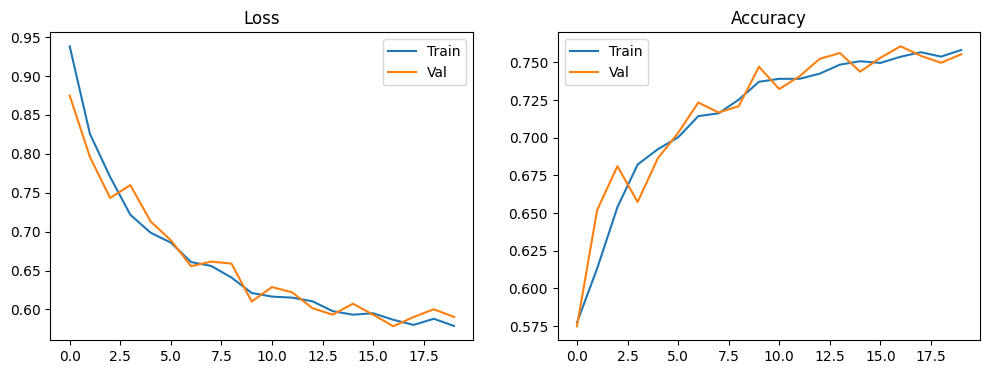

In [19]:

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title("Accuracy")

plt.show()


## 10. Visualize Predictions

In [20]:
def create_mask(pred_mask):
  pred_mask = tf.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = unet_model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(model.predict(sample_image[tf.newaxis, ...]))])

In [21]:
count = 0
for i in test_batches:
    count +=1
print("number of batches:", count)

number of batches: 11


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


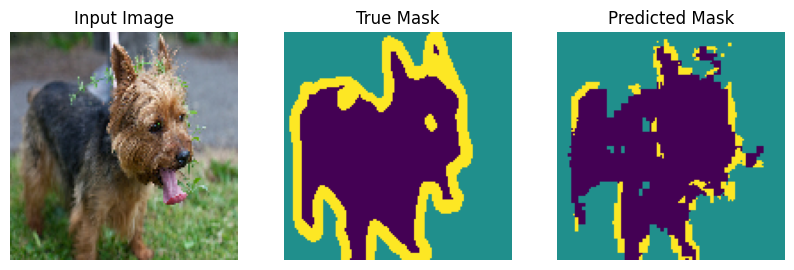

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


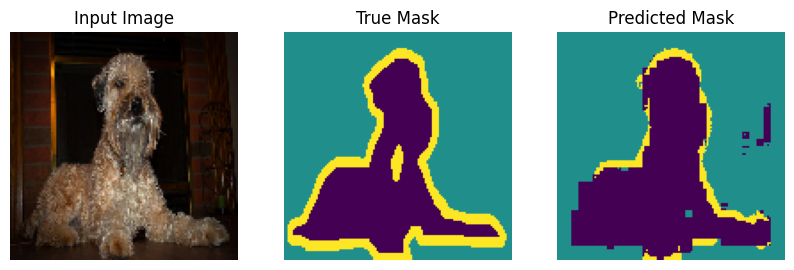

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


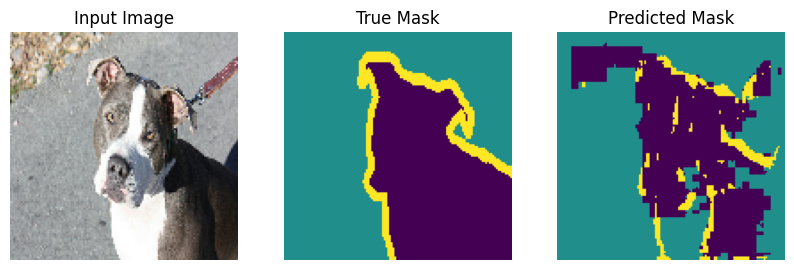

In [22]:
show_predictions(test_batches.skip(5), 3)

## 11. Tasks and questions


## Tasks

### T11.a) Try with more epochs, are 20 epochs sufficient?
To answer the question we will try to reinstate the model, this time with a much larger num_epoch, say 60. Then we will look for the built in early stop to be triggered, if it is triggered before 20 epochs then we can safely say that 20 was enough.

In [ ]:
NUM_EPOCHS = 60

model_simple_epoch_test = simple_unet()

model_simple_epoch_test.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])


callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

history_epoch_test = model_simple_epoch_test.fit(
    train_batches,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=validation_batches,
    epochs=NUM_EPOCHS,
    callbacks=callbacks
)


Epoch 1/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 356ms/step - accuracy: 0.5673 - loss: 0.9456 - val_accuracy: 0.5733 - val_loss: 0.8949
Epoch 2/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 353ms/step - accuracy: 0.6205 - loss: 0.8157 - val_accuracy: 0.6651 - val_loss: 0.7876
Epoch 3/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 391ms/step - accuracy: 0.6600 - loss: 0.7616 - val_accuracy: 0.6698 - val_loss: 0.7588
Epoch 4/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.6794 - loss: 0.7290 - val_accuracy: 0.6890 - val_loss: 0.7232
Epoch 5/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 373ms/step - accuracy: 0.6831 - loss: 0.7136 - val_accuracy: 0.6950 - val_loss: 0.7044
Epoch 6/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 400ms/step - accuracy: 0.6938 - loss: 0.6971 - val_accuracy: 0.7055 - val_loss: 0.6926
Epoch 7/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 393ms/step - accuracy: 0.6992 - loss: 0.6858 - val_accuracy: 0.7119 - val_loss: 0.6798
Epoch 8/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 398ms/step - accuracy: 0.7106 - loss: 0.6652 - val_accu

We see that the early stop is applied at epoch 26, then taking into account the patience of 5 epochs, the best result is about epoch 21, and so while 20 epochs is not far from the best, it would certainly make sense to use just one more epoch to really hit out tolerance. We also see the validation accuracy really does not improve from epoch 21 and onwards. And so 20 epochs is very close and 21 epochs is sufficient.

### T11.b) Study the large U-Net model and describe the differences from the simple U-Net model

The biggest difference between the large and simple U-net model is depth of the larger model. Where the simpel model only has two downsampling blocks before the bottleneck, whereas the larger model uses 4 downsampling blocks and gets to a bottleneck of 1024 filters, compared to the 128 of the simple model. On top of this the large model uses the double_conv_block function applying effectively two layers of the Conv2D at each step. Lastly the larger model uses dropouts to remain resiliant against overfitting and utilizes a kernel initializer which the simple model does not.

### T11.c) Select and add a method to measure performance such as accuracy for classification or MSE for regression
We choose to add the metric Mean IoU from chapter 14 of the book, as this is mentioned as the standard for Image Segmentation. First we need to conform the data from the softmax to integers which the MeanIoU expects:

In [57]:

class MyMeanIoU(tf.keras.metrics.MeanIoU):
    def __init__(self, num_classes=3, name='mean_iou', **kwargs):
        super().__init__(num_classes=num_classes, name=name, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Step 1: Turn probabilities (Softmax) into class IDs (0, 1, or 2)
        y_pred = tf.math.argmax(y_pred, axis=-1)
        # Step 2: Call the original MeanIoU logic with the corrected shapes
        return super().update_state(y_true, y_pred, sample_weight)

model_simple_with_IoU = simple_unet()

# Now we can call the compiler
model_simple_with_IoU.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", MyMeanIoU(num_classes=3)]
)

model_simple_with_IoU.fit(train_batches, epochs=21, steps_per_epoch=STEPS_PER_EPOCH)



Epoch 1/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 334ms/step - accuracy: 0.5728 - loss: 0.9370 - mean_iou: 0.2012
Epoch 2/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 354ms/step - accuracy: 0.6202 - loss: 0.8130 - mean_iou: 0.2858
Epoch 3/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 341ms/step - accuracy: 0.6649 - loss: 0.7528 - mean_iou: 0.3432
Epoch 4/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 347ms/step - accuracy: 0.6831 - loss: 0.7153 - mean_iou: 0.3796
Epoch 5/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 362ms/step - accuracy: 0.6957 - loss: 0.6931 - mean_iou: 0.4116
Epoch 6/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 367ms/step - accuracy: 0.7090 - loss: 0.6706 - mean_iou: 0.4297
Epoch 7/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 379ms/step - accuracy: 0.7187 - loss: 0.6526 - mean_iou: 0.4435
Epoch 8/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 365ms/step - accuracy: 0.7252 - loss: 0.6406 - mean_iou: 0.4520
Epoch 9/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 365ms/step - accuracy: 0.7299 - loss: 0.6343 - mean_iou: 0.4588
Epoch 10/21
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 365

In [ ]:
test_results = model_simple_with_IoU.evaluate(test_batches)


print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Mean IoU: {test_results[2]:.4f}")
print("We see a mean IoU of abnout 0.5, which is not horrible but considering the range of IoU is 0 to 1 with the closer to 1 the better, we are not yet near pefection")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.7644 - loss: 0.5662 - mean_iou: 0.5048
Test Loss: 0.5662
Test Accuracy: 0.7644
Test Mean IoU: 0.5048


The reason IoU ranges from 0 to 1 is found in its formula, it is a fraction: 
$IoU = \frac{AreaOverlap}{AreaUnion}$

### T11.d) Compare the performance of the large U-Net with the simple U-Net model

Now we unleash the large U-net and compare with the simple using the same metrics.

In [61]:
NUM_EPOCHS = 5 # Running 5 epochs gets better results than the 21 with the simple model, and is already much closer to 1h runtime than I am willing to suffer through



# Comment line to use large U-Net model
# unet_model = model_simple

unet_model = build_unet_model()
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", MyMeanIoU(num_classes=3)]
)

history = unet_model.fit(
    train_batches,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=validation_batches,
    epochs=NUM_EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 613s 11s/step - accuracy: 0.5729 - loss: 1.0316 - mean_iou: 0.2175 - val_accuracy: 0.6065 - val_loss: 0.8421 - val_mean_iou: 0.2826
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 573s 10s/step - accuracy: 0.6053 - loss: 0.8344 - mean_iou: 0.2732 - val_accuracy: 0.6339 - val_loss: 0.7918 - val_mean_iou: 0.3344
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 578s 10s/step - accuracy: 0.6819 - loss: 0.7327 - mean_iou: 0.3807 - val_accuracy: 0.7213 - val_loss: 0.6797 - val_mean_iou: 0.4354
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 630s 11s/step - accuracy: 0.7362 - loss: 0.6543 - mean_iou: 0.4420 - val_accuracy: 0.7551 - val_loss: 0.6102 - val_mean_iou: 0.4725
Epoch 5/5


KeyboardInterrupt: 

### T11.e) Compare performance at different input resolutions (Simple U-Net model)

## Questions

### Q11.a) How does segmentation differ from classification?
Classification is a bit more big picture oriented, meaning a classifier will focus on saying that is a dog (or cat or whatever), sometimes as simple as true or false. Segmentation on the other hand will try to draw a border of pixels outlining where in the picture the dog is. This is however also quite a task to perform and as we saw above can require a lot of time to get good results.

### Q11.b) What data augmentation is used and where?
We can see the augemtation happening in the preprocessing part, more specifically the 
"def augment(input_image, input_mask):
    if tf.random.uniform(()) > 0.5:
        # Random flipping of the image and mask
        input_image = tf.image.flip_left_right(input_image)
        input_mask = tf.image.flip_left_right(input_mask)"
        
Where we flip the pictures to ensure that the model does not learn general placements of the pets. But learns to look for pets wherever they might be. It is worth noting that we do not flip the test data, since we should avoid fiddling with that in most cases.


### Q11.b) What is the purpose of skip connections?
Skip connections, skip, some of the deepest layers and passes information on to the decoders, this is done as an attempt to recover some of spatial resolution, that might be lost otherwise when scaling all the way down to the bottleneck, where much less data is stored. 

### Deliverables:

- Completed notebook with experiments
- Plots and answers to questions
- Short written reflection on results

REVISIONS||
:- | :-
2022-01-23| KBE, initial. 
2026-03-19| KBE, updated task T11.c 
2026-03-19| KBE, added ['metrics']